In [51]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [52]:
df = pd.read_csv("smartcart_customers.csv")

In [53]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Preprocessing

In [54]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

 handle the null value of Income

In [55]:
df["Income"] = df["Income"].fillna(df["Income"].median())
df["Income"].isnull().sum()

np.int64(0)

#  Feature Engineering 

In [56]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [57]:
# Create the age 

df["Age"] = 2026 - df["Year_Birth"]

In [58]:
# Customer_ tenure 
df["Dt_Customer"] =pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_data = df["Dt_Customer"].max()
df["Customer_tensure"] = (reference_data - df["Dt_Customer"]).dt.days

In [59]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tensure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [60]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tensure'],
      dtype='object')

In [61]:
# Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] +df["MntMeatProducts"] +df["MntFishProducts"] +df["MntSweetProducts"] +df["MntGoldProds"]


In [62]:
# children

df["Total_children"] = df['Kidhome'] + df['Teenhome']

In [63]:
# education

df["Education"].value_counts()

# undergraduate
# graduate
# postgraduate

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate",
})

df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [64]:
df["Marital_Status"].value_counts()
df["Living_with"] =df["Marital_Status"].str.strip().replace({
    "Married": "Couple",
    "Together": "Couple",
    "Single": "Single",
    "Divorced": "Single",
    "Widow": "Single",
    "Alone": "Single",
    "YOLO": "Single",
    "Absurd": "Single",
})
df["Living_with"].value_counts()

Living_with
Couple    1444
Single     796
Name: count, dtype: int64

In [65]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tensure', 'Total_Spending',
       'Total_children', 'Living_with'],
      dtype='object')

In [66]:
# dropping

df_cleaned = df.drop(columns=["ID", "Year_Birth",
                      "Marital_Status",
                      "Kidhome", "Teenhome",
                      "Dt_Customer",
                      "MntWines", "MntFruits",
                      "MntMeatProducts", "MntFishProducts",
                      "MntSweetProducts", "MntGoldProds"])

In [67]:
df.shape

(2240, 27)

# Outlier

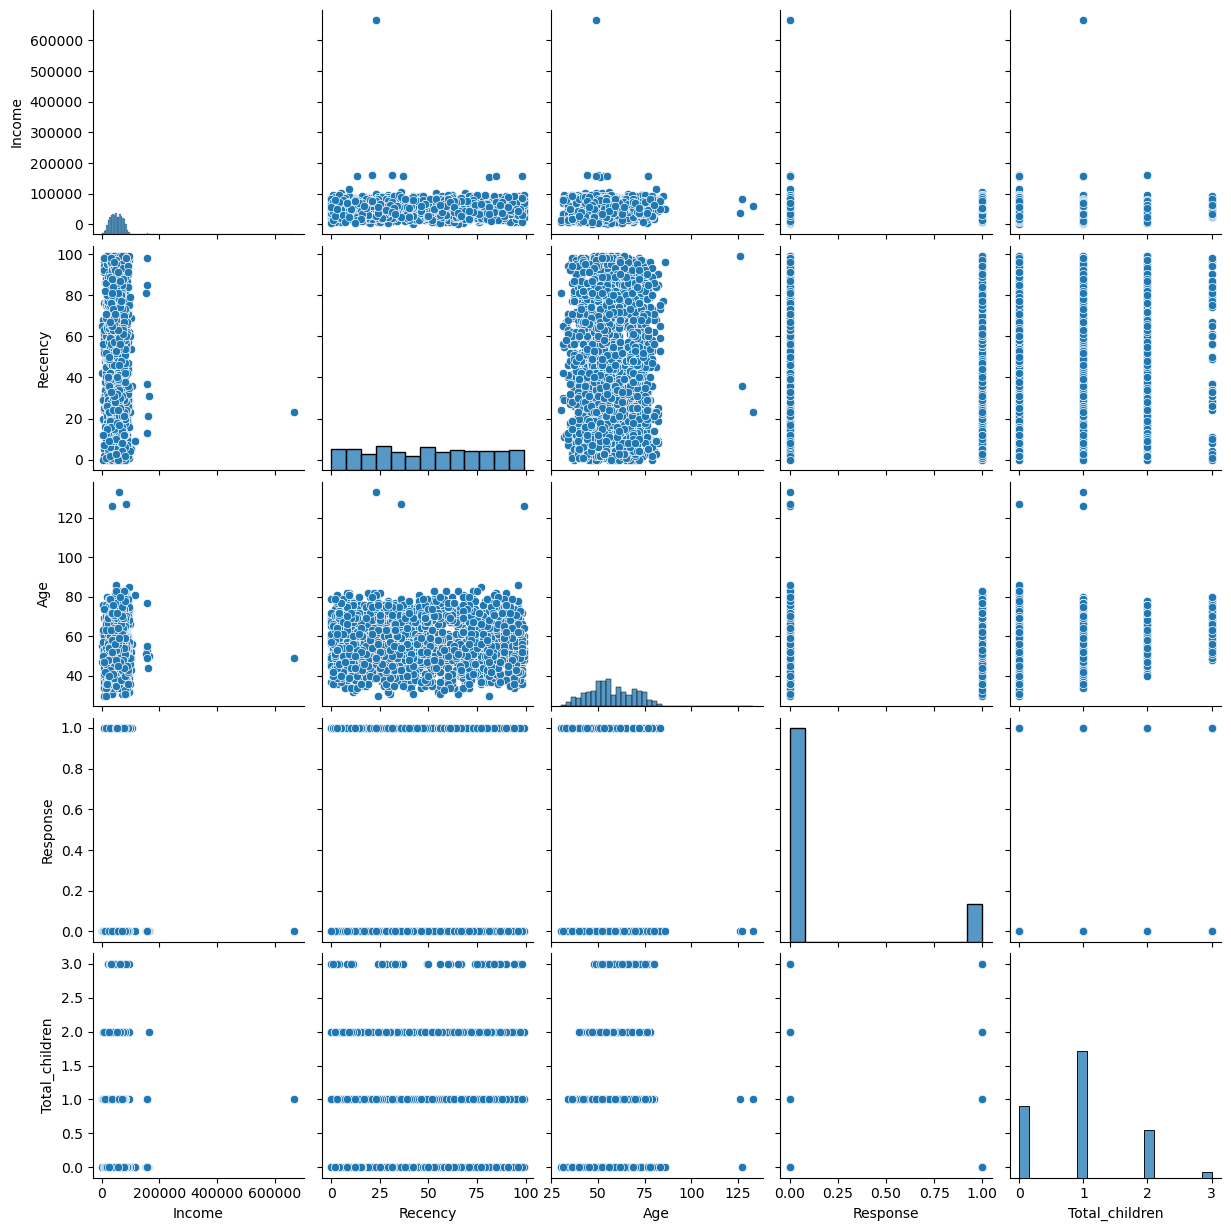

In [68]:
cols = ["Income" , "Recency" , "Age","Response","Total_children"]

# relative plot  - pair plot 
sns.pairplot(df_cleaned[cols])

In [69]:
#Remove 

df_cleaned = df_cleaned[df_cleaned['Age']<90]
df_cleaned =df_cleaned[df_cleaned['Income']< 600_000]

# Correlation

In [70]:
corr =df_cleaned.corr(numeric_only=True)
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tensure,Total_Spending,Total_children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


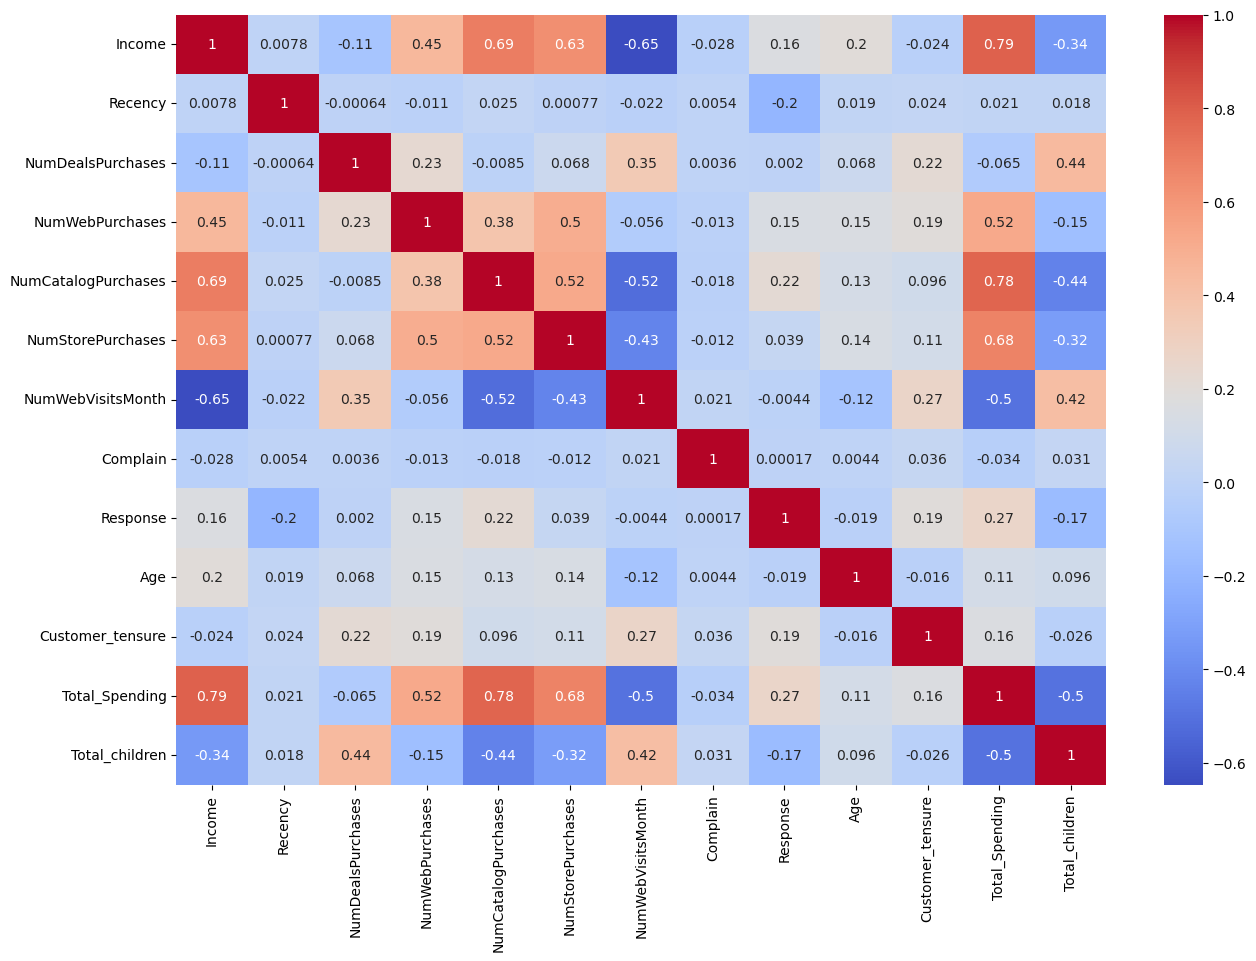

In [71]:

plt.figure(figsize=(15,10))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 10},
    cmap="coolwarm",
)
plt.show()

Feature encoding 

In [72]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tensure', 'Total_Spending',
       'Total_children', 'Living_with'],
      dtype='object')

In [73]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder()

cat_cols = ["Education","Living_with"]

enc_cols = enc.fit_transform(df_cleaned[cat_cols])

In [74]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=enc.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [75]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols, axis=1), enc_df], axis=1)
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tensure,Total_Spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Couple,Living_with_Single
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,0.0,1.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,0.0,1.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,1.0,0.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,1.0,0.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,0.0,1.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,1.0,0.0


In [76]:
X = df_encoded

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Visualise 

In [78]:
# PCA 
#2d 

from sklearn.decomposition import PCA 

pca = PCA(
    n_components=3
)
X_pca = pca.fit_transform(X_scaled)


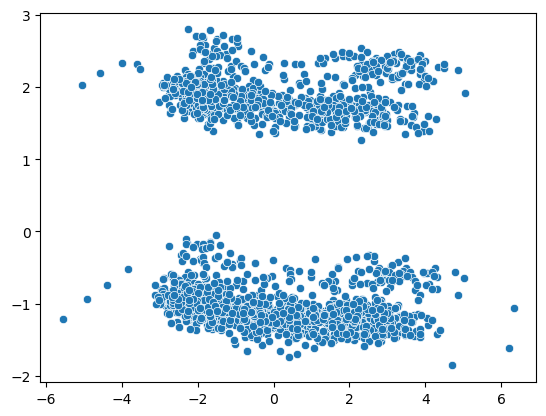

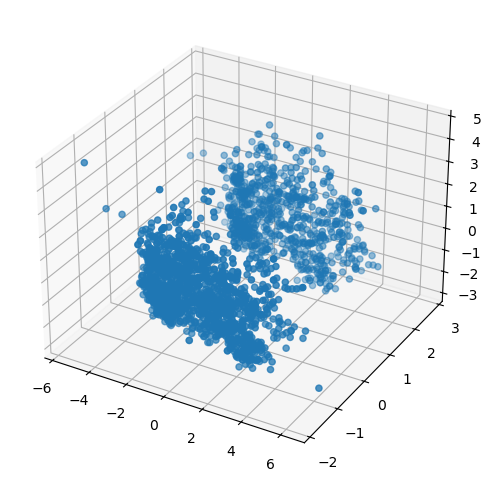

In [79]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1])
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

In [80]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# K_mean 

In [81]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmean = KMeans(n_clusters=k,random_state=42)
    kmean.fit_predict(X_pca)
    wcss.append(kmean.inertia_)

c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [82]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")

optimal_k = knee.elbow

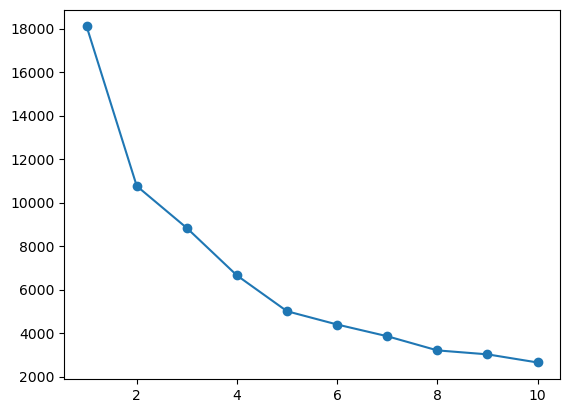

In [83]:
plt.plot(range(1,11),wcss,marker="o")

In [84]:
print("Best K",optimal_k)

Best K 4


In [85]:
from sklearn.metrics import silhouette_score

c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

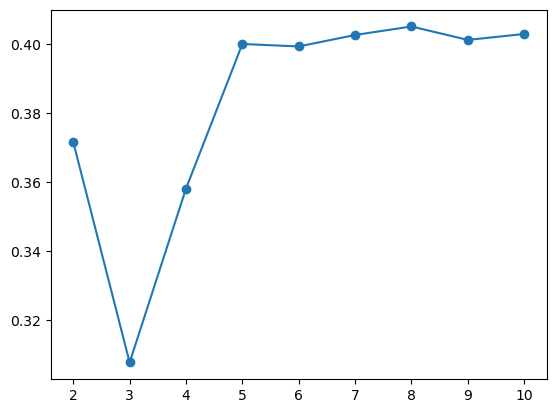

In [86]:
scores = []

for k in range(2,11):
    kmean = KMeans(n_clusters=k,random_state=42)
    label = kmean.fit_predict(X_pca)
    score = silhouette_score(X_pca,label)
    scores.append(score)


plt.plot(range(2,11),scores,marker="o")

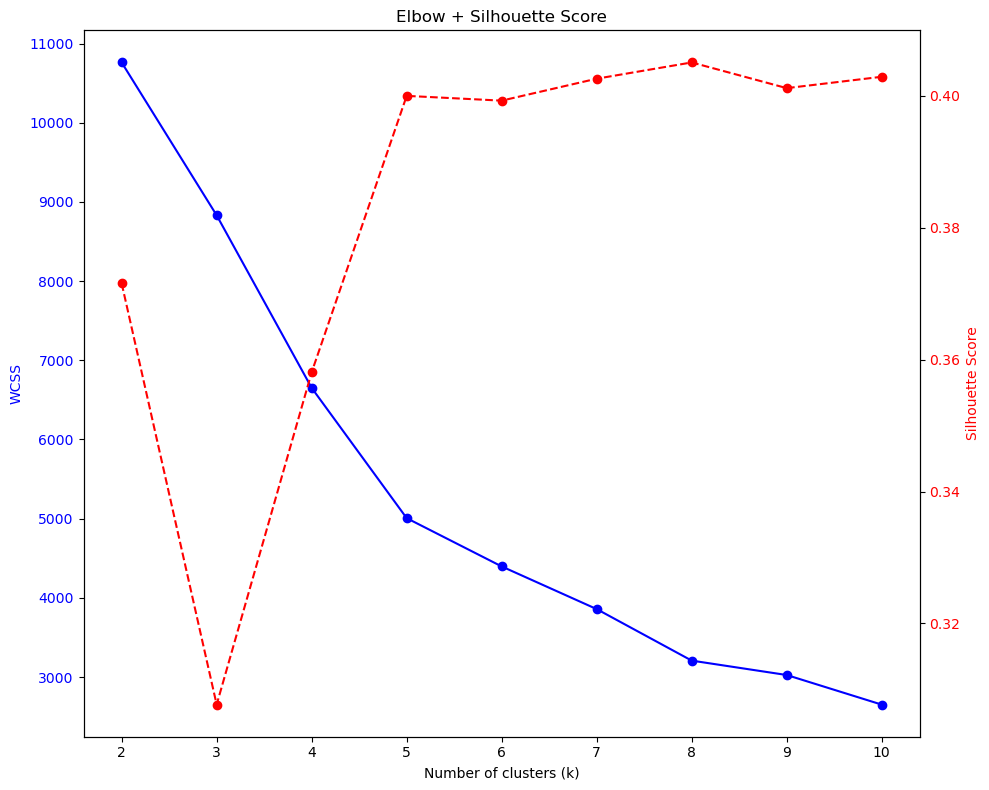

In [87]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(10, 8))

# WCSS for k=2..10 (skip k=1)
ax1.plot(k_range, wcss[1:len(k_range)+1], marker="o", color="blue", label="WCSS")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("WCSS", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_title("Elbow + Silhouette Score")

# Silhouette score for k=2..10
ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="o", linestyle="--", color="red", label="Silhouette")
ax2.set_ylabel("Silhouette Score", color="red")
ax2.tick_params(axis="y", labelcolor="red")

fig.tight_layout()
plt.show()

# Clustering 

In [88]:
kmean = KMeans(n_clusters=4 , random_state=42)

K_label = kmean.fit_predict(X_pca)



c:\Users\gk480\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


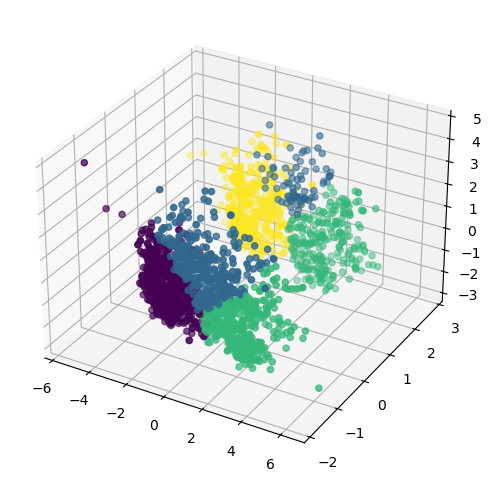

In [89]:

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c= K_label)

In [90]:
# A

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4,
                                  linkage="ward")

agg_label = agg_clf.fit_predict(X_pca)



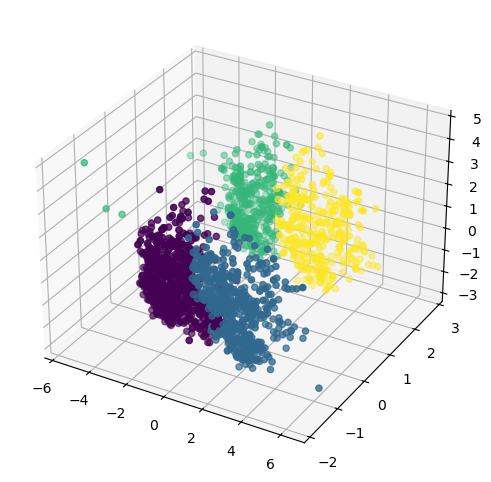

In [91]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c= agg_label)

# Characterization of Cluster 

In [92]:
df_cleaned["cluster"] = agg_label

In [93]:
pl = ["Red", "Blue","Green " , "Yello"]

<Axes: xlabel='cluster', ylabel='count'>

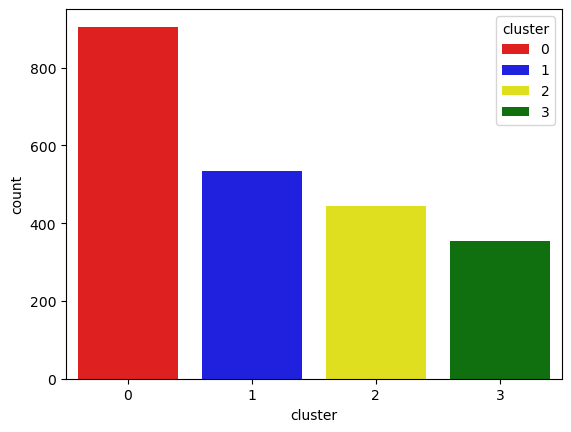

In [100]:
pl_fixed = ["Red", "Blue", "Yellow", "Green"]
sns.countplot(x=df_cleaned["cluster"], palette=pl_fixed, hue=df_cleaned["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

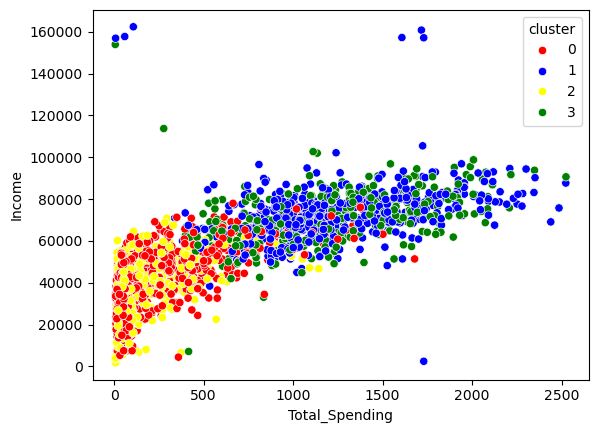

In [101]:
# income and spending pattern 

sns.scatterplot(x=df_cleaned["Total_Spending"],y=df_cleaned["Income"],hue=df_cleaned["cluster"],palette=pl_fixed)

In [104]:
# cluster summary

cluster_summ = df_cleaned.groupby("cluster").mean()

print(cluster_summ)

TypeError: agg function failed [how->mean,dtype->object]